In [1]:
!pip install opencv-python


In [2]:
import cv2
import matplotlib.pyplot as plt

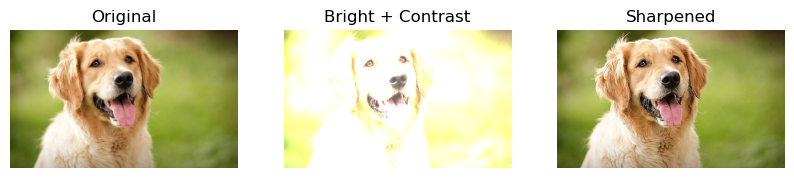

In [3]:
#image enhancement
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("dog.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #Brightness + Contrast
bright = cv2.convertScaleAbs(img, alpha=2, beta=90)
bright_rgb = cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)

    #Sharpening
kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
sharp = cv2.filter2D(img, -1, kernel)
sharp_rgb = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bright_rgb)
plt.title("Bright + Contrast")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharp_rgb)
plt.title("Sharpened")
plt.axis('off')

plt.show()

C:\Users\Keerthana\AppData\Local\Temp\ipykernel_20000\1233447269.py:29: RuntimeWarning: invalid value encountered in cast
  ldr = np.clip(ldr * 255, 0, 255).astype('uint8')


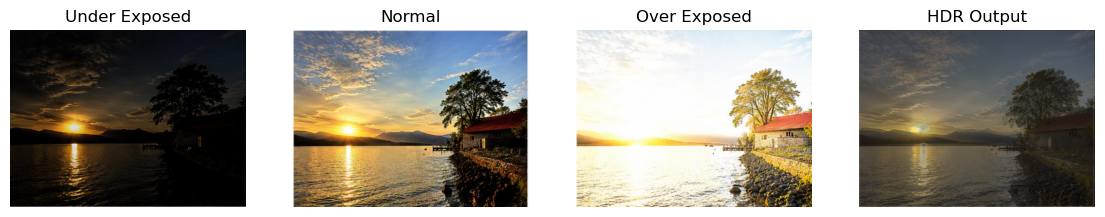

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read images
img1 = cv2.imread("under_expo.jpeg")
img2 = cv2.imread("normal.jpeg")
img3 = cv2.imread("over_expo.jpeg")

# Resize images
size = (400, 300)

img1 = cv2.resize(img1, size)
img2 = cv2.resize(img2, size)
img3 = cv2.resize(img3, size)

# Exposure times
times = np.array([1/30.0, 0.25, 2.5], dtype=np.float32)

# HDR creation
merge_debevec = cv2.createMergeDebevec()
hdr = merge_debevec.process([img1, img2, img3], times)

# Tone mapping
tonemap = cv2.createTonemap(gamma=2.2)
ldr = tonemap.process(hdr)

# Convert HDR output to uint8
ldr = np.clip(ldr * 255, 0, 255).astype('uint8')

# Convert BGR to RGB
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
ldr_rgb = cv2.cvtColor(ldr, cv2.COLOR_BGR2RGB)

# Display all images
plt.figure(figsize=(14, 6))

plt.subplot(1,4,1)
plt.imshow(img1_rgb)
plt.title("Under Exposed")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(img2_rgb)
plt.title("Normal")

plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img3_rgb)
plt.title("Over Exposed")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(ldr_rgb)
plt.title("HDR Output")
plt.axis('off')

plt.show()